# P1 프로젝트: 자전거 수요 예측

워싱턴 D.C. 자전거 공유 서비스의 시간당 대여량을 예측한다.

> **2011년 데이터로 학습한 머신러닝 모델은 2012년의 시간당 자전거 대여량을 얼마나 잘 예측할 수 있는가?**

이번 프로젝트는 여러분이 처음으로 **머신러닝 프로젝트의 전체 흐름을 직접 따라가는 프로젝트**다.  
코드를 많이 작성하는 것이 목적은 아니다. 제공된 코드를 활용하고 AI의 도움을 받아도 된다.

중요한 것은 다음 판단을 직접 하는 것이다.

- 무엇을 예측할 것인가?
- 어떤 정보를 모델에 사용할 것인가?
- 어떤 데이터로 모델을 선택하고, 어떤 데이터로 최종 평가할 것인가?
- 어떤 모델을 선택할 것인가?
- 성능 숫자를 어떻게 해석할 것인가?
- 모델이 언제 잘못되는가?
- 결과를 어디까지 믿을 수 있는가?

이 노트북은 정답지가 아니라 **프로젝트 길안내서**다.

**프로젝트 진행 원칙**

프로젝트를 진행하는 동안 다음 네 가지 원칙을 지킨다.

1. **2012년 데이터는 최종 평가 전까지 보지 않는다.**  
   모델 선택은 2011년 데이터 안에서 끝낸다.

2. **모델에게 정답과 사실상 같은 정보를 주지 않는다.**  
   타깃 `cnt`와 직접 연결된 변수는 입력 특성에서 제외한다.

3. **그래프를 그리기 전에 질문을 먼저 정한다.**  
   EDA는 그림을 많이 만드는 활동이 아니라 데이터에 관한 질문에 답하는 과정이다.

4. **AI는 도구로 사용하고 판단은 직접 한다.**  
   코드 작성·오류 수정·설명 초안은 AI에게 도움을 받을 수 있다.  
   하지만 특성 선택, 모델 선택, 결과 해석, 한계 판단은 자신의 근거를 남겨야 한다.

**환경설정**

In [ ]:
import sys
import sklearn
from packaging.version import Version

# 파이썬 버전과 scikit-learn 버전 확인
assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 1단계 — 문제 정의, 데이터 이해, EDA

### 문제를 데이터의 언어로 바꾼다

먼저 코드를 실행하기 전에 분석 문제를 정리한다.

- **샘플**: 한 시간의 관측값
- **타깃**: 시간당 전체 자전거 대여량 `cnt`
- **특성 후보**: 시간, 계절, 월, 요일, 휴일, 근무일, 날씨, 온도, 체감온도, 습도, 풍속
- **문제 유형**: 타깃이 수치이므로 **회귀**
- **과거 데이터**: 2011년
- **미래 데이터**: 2012년

이번 프로젝트에서는 임의로 데이터를 섞지 않고 **과거로 학습하고 미래에서 평가하는 상황**을 그대로 사용한다.

#### 프로젝트 기록 ① — 분석 설계

다음을 자신의 말로 작성한다.

**분석 목적**

> 작성:

**타깃**

> 작성:

**회귀 문제라고 판단한 이유**

> 작성:

**2011년과 2012년의 역할**

> 작성:

### 데이터를 불러와 구조를 확인한다

아래 코드는 **제공 코드**다. 외우는 것이 목적이 아니다.  
실행한 뒤 데이터의 행과 열이 무엇을 의미하는지 확인한다.

In [ ]:
# UCI Bike Sharing 데이터 불러오기
# 처음 실행할 때 인터넷 연결이 필요하다.

from ucimlrepo import fetch_ucirepo

bike = fetch_ucirepo(id=275)

parts = []

if bike.data.features is not None:
    parts.append(bike.data.features.copy())

if bike.data.targets is not None:
    parts.append(bike.data.targets.copy())

if getattr(bike.data, "ids", None) is not None:
    parts.append(bike.data.ids.copy())

df = pd.concat(parts, axis=1)
df = df.loc[:, ~df.columns.duplicated()]

# 날짜는 이후 시간 순서 정렬에 사용한다.
df["dteday"] = pd.to_datetime(df["dteday"])

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (17379, 15)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,instant
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,2
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,3
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,4
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,5


In [2]:
# 필요한 기본 열이 제대로 들어왔는지 확인한다.
required_cols = {
    "instant", "dteday", "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed", "cnt"
}

missing_cols = sorted(required_cols - set(df.columns))

if missing_cols:
    raise ValueError(f"필요한 열이 없습니다: {missing_cols}")

print("기본 열 확인 완료")
print(df.columns.tolist())

기본 열 확인 완료
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'instant']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[us]
 1   season      17379 non-null  int64         
 2   yr          17379 non-null  int64         
 3   mnth        17379 non-null  int64         
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  int64         
 6   weekday     17379 non-null  int64         
 7   workingday  17379 non-null  int64         
 8   weathersit  17379 non-null  int64         
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  cnt         17379 non-null  int64         
 14  instant     17379 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(10)
memory usage: 2.0 MB


In [4]:
# 결측치가 있는 열부터 확인한다.
df.isna().sum().sort_values(ascending=False).head(20)

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
instant       0
dtype: int64

#### 데이터에서 확인할 것

출력 결과를 보고 다음 질문에 답한다.

1. 전체 샘플 수와 변수 수는 얼마인가?
2. 결측치는 있는가?
3. 숫자로 저장되어 있지만 실제로는 범주를 나타내는 변수는 무엇인가?
4. 날짜와 시간 정보는 어떤 변수에 들어 있는가?
5. `cnt`는 무엇을 의미하는가?

**관찰 기록**

> 작성:

### 모델링 전에 데이터 누수를 점검한다

UCI의 원자료에는 다음 세 대여량 변수가 정의되어 있다.

- `casual`: 비등록 사용자의 대여 건수
- `registered`: 등록 사용자의 대여 건수
- `cnt`: 전체 대여 건수

그리고 원자료에서는 다음 관계가 성립한다.

> **`cnt = casual + registered`**

따라서 원자료를 직접 불러와 `casual`, `registered`가 포함되어 있다면  
`cnt`를 예측하는 모델의 입력 특성으로 사용하면 안 된다. 정답을 사실상 모델에게 알려주는 **데이터 누수**가 되기 때문이다.

현재 `ucimlrepo`에서 `features`, `targets`, `ids`를 합친 데이터에는 이 두 열이 포함되지 않을 수 있다.  
아래에서 UCI가 제공하는 변수 설명과 현재 데이터의 열을 함께 확인한다.

In [5]:
# UCI 변수 설명에서 대여량 관련 변수를 확인한다.
bike.variables.loc[
    bike.variables["name"].isin(["casual", "registered", "cnt"]),
    ["name", "role", "type", "description"]
]

,name,role,type,description
14,casual,Other,Integer,count of casual users
15,registered,Other,Integer,count of registered users
16,cnt,Target,Integer,count of total rental bikes including both cas...


In [6]:
# 현재 불러온 데이터에 세 열이 실제로 있는지 확인한다.
rental_cols = [c for c in ["casual", "registered", "cnt"] if c in df.columns]

print("현재 데이터에 포함된 대여량 관련 열:", rental_cols)

if {"casual", "registered", "cnt"}.issubset(df.columns):
    display(df[["casual", "registered", "cnt"]].head())
    print(
        "cnt = casual + registered가 모든 행에서 성립:",
        (df["cnt"] == df["casual"] + df["registered"]).all()
    )
else:
    print("casual/registered는 현재 분석 데이터에 포함되어 있지 않습니다.")
    print("다른 방식으로 원자료를 불러올 경우에는 두 열을 입력 특성에서 반드시 제외합니다.")

현재 데이터에 포함된 대여량 관련 열: ['cnt']
casual/registered는 현재 분석 데이터에 포함되어 있지 않습니다.
다른 방식으로 원자료를 불러올 경우에는 두 열을 입력 특성에서 반드시 제외합니다.


데이터 누수는 단순한 코드 오류가 아니다.

> **미래에 실제 예측 시점에서 사용할 수 없는 정보나, 타깃을 사실상 알려주는 정보를 모델에 넣는 분석 설계의 오류**다.

이번 프로젝트에서는 다음 열을 모델 입력에서 제외한다.

- `instant`: 단순한 행 번호
- `dteday`: 날짜 자체는 시간 순서 정렬에 사용하고 기본 모델 입력에서는 제외
- `yr`: 2011년과 2012년을 분리하기 위한 변수
- `cnt`: 타깃
- `casual`, `registered`: 데이터에 존재한다면 누수를 일으키므로 제외

#### 프로젝트 기록 ② — 제외할 변수

| 변수 | 제외하는 이유 |
|---|---|
| `instant` | 작성 |
| `dteday` | 작성 |
| `yr` | 작성 |
| `cnt` | 작성 |
| `casual` | 작성 |
| `registered` | 작성 |

**누수 여부를 확인하지 않고 성능 숫자만 비교하면 왜 위험한가?**

> 작성:

### 2012년을 최종 평가 데이터로 보존한다

`yr`는 다음을 의미한다.

- `0` → 2011년
- `1` → 2012년

이번 프로젝트의 역할은 다음처럼 고정한다.

> **2011년: 탐색 · 학습 · 모델 선택**  
> **2012년: 최종 평가**

여기서부터 모델 선택이 끝날 때까지 **2012년의 타깃 분포나 모델 성능을 확인하지 않는다.**

In [7]:
df_2011 = df.loc[df["yr"] == 0].copy()
df_2012 = df.loc[df["yr"] == 1].copy()

print("2011년 데이터:", df_2011.shape)
print("2012년 데이터:", df_2012.shape)

print(
    "2011년 기간:",
    df_2011["dteday"].min().date(),
    "~",
    df_2011["dteday"].max().date()
)
print(
    "2012년 기간:",
    df_2012["dteday"].min().date(),
    "~",
    df_2012["dteday"].max().date()
)

2011년 데이터: (8645, 15)
2012년 데이터: (8734, 15)
2011년 기간: 2011-01-01 ~ 2011-12-31
2012년 기간: 2012-01-01 ~ 2012-12-31


### 모델을 만들기 전에 2011년 데이터를 탐색한다

EDA는 **2011년 데이터만** 사용한다.

먼저 타깃의 분포를 확인한다.

> **질문:** 대부분의 시간대에서 대여량은 어느 정도이며, 매우 높은 수요도 자주 나타나는가?

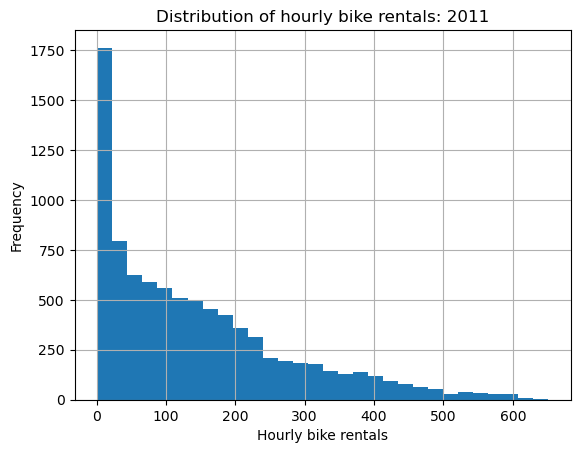

In [8]:
df_2011["cnt"].hist(bins=30)

plt.xlabel("Hourly bike rentals")
plt.ylabel("Frequency")
plt.title("Distribution of hourly bike rentals: 2011")
plt.show()

#### 시간대에 따라 수요가 달라질까?

> **질문:** 하루 중 어느 시간에 평균 대여량이 높고 낮은가?

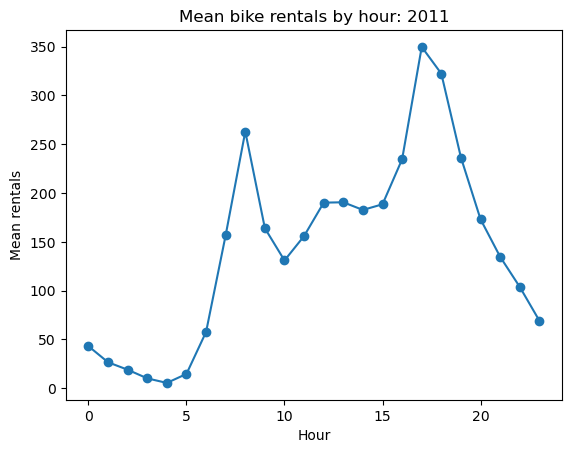

In [9]:
hourly = df_2011.groupby("hr")["cnt"].mean()

hourly.plot(marker="o")

plt.xlabel("Hour")
plt.ylabel("Mean rentals")
plt.title("Mean bike rentals by hour: 2011")
plt.show()

#### 근무일과 비근무일의 시간대별 패턴은 같을까?

전체 평균만 보면 서로 다른 이용 목적이 섞일 수 있다.  
출퇴근 수요가 존재한다면 `workingday`에 따라 시간대별 모습이 달라질 수 있다.

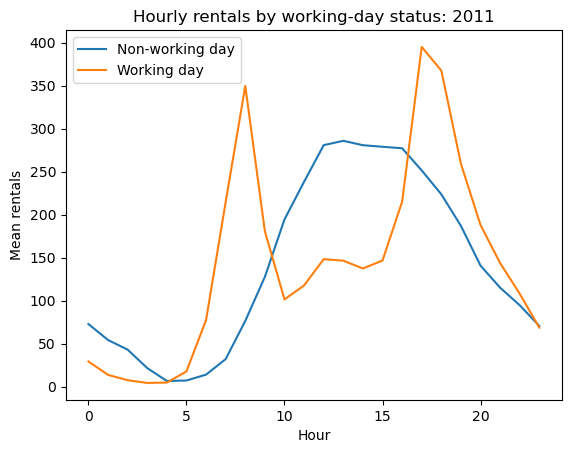

In [10]:
hour_work = (
    df_2011.groupby(["hr", "workingday"])["cnt"]
           .mean()
           .unstack()
)

hour_work.columns = ["Non-working day", "Working day"]

hour_work.plot()

plt.xlabel("Hour")
plt.ylabel("Mean rentals")
plt.title("Hourly rentals by working-day status: 2011")
plt.show()

#### 나만의 EDA 질문 하나를 만든다

아래 변수 중 하나 이상을 사용하여 **자신의 질문**을 만든다.

`season`, `mnth`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`

예:

- 날씨 상태에 따라 평균 대여량은 얼마나 다른가?
- 온도와 자전거 대여량 사이에는 어떤 관계가 보이는가?
- 계절별 시간대 패턴은 서로 다른가?

AI에게 코드를 제안받아도 된다. 다만 먼저 **질문을 한 문장으로 작성한 뒤** 코드를 요청한다.

**나의 질문**

> 작성:

In [11]:
# TODO
# 위에서 정한 EDA 질문을 확인하는 코드를 작성한다.
# 막히면 자신의 질문과 사용할 변수를 AI에게 알려주고 코드 제안을 받아도 된다.

#### AI 체크포인트 ① — EDA

AI에게 다음처럼 요청할 수 있다.

> “내 질문은 ______이다. `df_2011`에서 이 질문을 확인할 수 있는 간단한 pandas/matplotlib 코드를 제안해줘.  
> 그래프를 그리는 이유와 출력에서 무엇을 확인해야 하는지도 설명해줘.”

AI의 코드를 그대로 실행하기 전에 확인한다.

- 2012년 데이터를 사용하지 않았는가?
- 질문에 필요한 변수만 사용했는가?
- 그래프가 실제 질문에 답하는가?
- AI의 해석이 그래프에서 직접 확인되는가?

#### 프로젝트 기록 ③ — EDA에서 발견한 것

최소 세 가지를 기록한다.

**발견 1**

- 관찰:
- 모델링과의 연결:

**발견 2**

- 관찰:
- 모델링과의 연결:

**발견 3**

- 관찰:
- 모델링과의 연결:

단순히 “증가했다”, “차이가 있다”에서 끝내지 않는다.

> **그래서 어떤 정보가 예측에 유용할 것 같은가?  
> 모델이 어떤 관계를 표현해야 할 것 같은가?**

### 입력 특성과 타깃을 확정한다

숫자로 저장되어 있다고 해서 모든 변수가 연속적인 양을 뜻하지는 않는다.

예를 들어

- `hr=23`이 `hr=1`보다 23배 큰 시간이라는 뜻은 아니다.
- `season=4`가 `season=2`보다 두 배 큰 계절이라는 뜻도 아니다.

따라서 다음 변수는 기본 분석에서 **범주형 변수**로 다룬다.

`season`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`

나머지 날씨 관련 연속형 변수는 수치형으로 처리한다.

In [12]:
target = "cnt"

exclude_cols = [
    "instant", "dteday", "yr", target,
    "casual", "registered"
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

categorical_cols = [
    c for c in [
        "season", "mnth", "hr", "holiday",
        "weekday", "workingday", "weathersit"
    ]
    if c in feature_cols
]

numeric_cols = [
    c for c in feature_cols
    if c not in categorical_cols
]

print("타깃:", target)
print("사용 특성:", feature_cols)
print("범주형:", categorical_cols)
print("수치형:", numeric_cols)

타깃: cnt
사용 특성: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
범주형: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
수치형: ['temp', 'atemp', 'hum', 'windspeed']


#### 1단계 마무리 체크

다음 질문에 답할 수 있으면 2차시로 넘어간다.

- 무엇을 예측하는가?
- 왜 이 문제는 회귀인가?
- 왜 2012년을 아직 분석하지 않는가?
- 누수를 일으킬 수 있는 변수는 무엇인가?
- 어떤 변수를 범주형으로 처리하는가?
- EDA에서 발견한 사실이 모델링과 어떻게 연결되는가?

## 2단계 — 전처리, 모델 훈련, 검증과 선택

### 2011년 안에서 학습용과 검증용 데이터를 다시 나눈다

2012년은 최종 평가용이므로 모델 선택에 사용할 수 없다.

따라서 2011년을 시간 순서대로 정렬한 뒤

- 앞 80% → **모델 학습용**
- 뒤 20% → **모델 선택용 검증**

으로 사용한다.

여기서도 무작위로 섞지 않는다.  
미래에 가까운 구간을 검증에 두어 실제 예측 상황과 비슷하게 만든다.

In [13]:
df_2011_ordered = (
    df_2011
    .sort_values(["dteday", "hr"])
    .reset_index(drop=True)
)

split_idx = int(len(df_2011_ordered) * 0.8)

dev_df = df_2011_ordered.iloc[:split_idx].copy()
val_df = df_2011_ordered.iloc[split_idx:].copy()

X_dev = dev_df[feature_cols]
y_dev = dev_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

print("모델 학습용:", X_dev.shape)
print(
    "기간:",
    dev_df["dteday"].min().date(),
    "~",
    dev_df["dteday"].max().date()
)

print()

print("모델 선택용 검증:", X_val.shape)
print(
    "기간:",
    val_df["dteday"].min().date(),
    "~",
    val_df["dteday"].max().date()
)

모델 학습용: (6916, 11)
기간: 2011-01-01 ~ 2011-10-20

모델 선택용 검증: (1729, 11)
기간: 2011-10-20 ~ 2011-12-31


### 전처리를 모델과 하나의 파이프라인으로 묶는다

기본 전처리는 다음과 같다.

- **수치형 변수** → 결측치 처리 + 표준화
- **범주형 변수** → 결측치 처리 + 원-핫 인코딩

현재 데이터에 결측치가 없더라도 같은 분석 절차를 다른 데이터에도 적용할 수 있도록 전처리를 명시한다.

특히 Ridge는 가중치에 규제를 적용하므로 수치형 특성의 스케일을 맞추는 것이 중요하다.

> 핵심은 클래스 이름을 외우는 것이 아니라  
> **어떤 종류의 데이터에 어떤 전처리가 왜 필요한지 설명하는 것**이다.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

전처리를 `Pipeline` 안에 넣는 이유도 중요하다.

모델을 학습할 때는 **학습 데이터로만 전처리 방법을 학습**하고,  
검증 데이터와 나중의 2012년 데이터에는 학습된 전처리를 그대로 적용해야 한다.

즉,

> **학습 데이터에 `fit` → 검증·테스트 데이터에는 `transform`**

원칙을 파이프라인이 자동으로 지켜 준다.

### 기준선과 여러 회귀 모델을 비교한다

처음부터 복잡한 모델을 많이 사용하는 것이 목적은 아니다.  
이번 프로젝트에서는 비교 이유가 분명한 모델만 사용한다.

#### 기준선 모델

`DummyRegressor`는 입력 특성을 이용하지 않고 평균값과 같은 단순한 예측만 한다.

> 머신러닝 모델이 이 기준선보다도 좋아지지 않는다면  
> 복잡한 모델을 사용하는 의미를 다시 생각해야 한다.

#### 선형 회귀

규제를 사용하지 않는 기본 선형 회귀 모델이다.

#### Ridge 회귀

선형 회귀의 가중치가 지나치게 커지지 않도록 규제를 적용한다.  
규제 강도 `alpha`를 여러 값으로 바꾸어 검증 성능을 비교한다.

In [15]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

def make_pipeline(estimator):
    return Pipeline([
        ("prep", clone(preprocess)),
        ("model", estimator)
    ])

models = {
    "Baseline(mean)": make_pipeline(
        DummyRegressor(strategy="mean")
    ),
    "LinearRegression": make_pipeline(
        LinearRegression()
    )
}

alpha_candidates = [0.01, 0.1, 1, 10, 100]

for alpha in alpha_candidates:
    models[f"Ridge(alpha={alpha})"] = make_pipeline(
        Ridge(alpha=alpha)
    )

print("비교할 모델:")
for name in models:
    print("-", name)

비교할 모델:
- Baseline(mean)
- LinearRegression
- Ridge(alpha=0.01)
- Ridge(alpha=0.1)
- Ridge(alpha=1)
- Ridge(alpha=10)
- Ridge(alpha=100)


### 같은 기준으로 모델을 검증한다

이번 프로젝트에서는 세 가지 지표를 함께 본다.

- **MAE**: 실제 대여량에서 평균적으로 몇 대 정도 벗어나는가?
- **RMSE**: 큰 오차에 더 큰 영향을 주었을 때 전체 오차는 어느 정도인가?
- **R²**: 타깃의 변동을 모델이 어느 정도 설명하는가?

모델 선택의 **주요 기준은 검증 RMSE**로 두되,  
훈련 성능과 검증 성능의 차이, MAE와 R²도 함께 확인한다.

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_scores(model, X, y):
    pred = model.predict(X)

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred)
    }

validation_rows = []

for name, model in models.items():
    model.fit(X_dev, y_dev)

    train_scores = regression_scores(model, X_dev, y_dev)
    val_scores = regression_scores(model, X_val, y_val)

    validation_rows.append({
        "Model": name,
        "Train MAE": train_scores["MAE"],
        "Validation MAE": val_scores["MAE"],
        "Train RMSE": train_scores["RMSE"],
        "Validation RMSE": val_scores["RMSE"],
        "Train R2": train_scores["R2"],
        "Validation R2": val_scores["R2"]
    })

validation_results = (
    pd.DataFrame(validation_rows)
      .set_index("Model")
      .sort_values("Validation RMSE")
)

validation_results["RMSE gap"] = (
    validation_results["Validation RMSE"]
    - validation_results["Train RMSE"]
)

validation_results

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,RMSE gap
Model,,,,,,,
Ridge(alpha=10),57.596339,52.307673,75.887855,73.340528,0.693264,0.622727,-2.547327
Ridge(alpha=1),57.501828,52.607596,75.799640,74.026202,0.693977,0.615639,-1.773438
Ridge(alpha=0.1),57.497543,52.644112,75.798244,74.116626,0.693988,0.614700,-1.681618
Ridge(alpha=0.01),57.497136,52.647065,75.798223,74.125121,0.693989,0.614611,-1.673102
LinearRegression,57.495866,52.658459,75.798199,74.131058,0.693989,0.614550,-1.667141
Ridge(alpha=100),60.427490,53.192895,79.719809,74.550983,0.661505,0.610170,-5.168826
Baseline(mean),109.147265,98.943382,137.021954,120.143076,0.000000,-0.012431,-16.878879


In [17]:
# 검증 RMSE만 기준으로 하면 가장 낮은 모델은 무엇인지 확인한다.
suggested_model_name = validation_results["Validation RMSE"].idxmin()

print("검증 RMSE 기준 후보:", suggested_model_name)

검증 RMSE 기준 후보: Ridge(alpha=10)


#### 프로젝트 기록 ④ — 모델 선택

표를 보고 직접 판단한다.

**1. 기준선보다 실제 모델의 성능이 좋아졌는가?**

> 작성:

**2. 검증 RMSE가 가장 낮은 모델은 무엇인가?**

> 작성:

**3. 훈련 RMSE와 검증 RMSE의 차이가 큰 모델이 있는가? 무엇을 의미할 수 있는가?**

> 작성:

**4. Ridge에서 `alpha`가 달라지면서 검증 성능은 어떻게 달라졌는가?**

> 작성:

**5. 최종적으로 어떤 모델을 선택할 것인가?**

> 작성:

**6. 선택 근거를 3~5문장으로 설명한다.**

> 작성:

#### AI 체크포인트 ② — 모델 선택 결과 검토

`validation_results` 표와 자신의 해석을 AI에게 보여 주고 다음처럼 요청할 수 있다.

> “이 표에서 각 모델의 훈련 성능과 검증 성능을 비교해줘.  
> 과소적합이나 과대적합 가능성이 있는지도 설명해줘.  
> 단, 최종 모델을 대신 결정하지 말고 내가 확인해야 할 근거를 알려줘.”

AI의 설명을 받은 뒤 다음을 확인한다.

- 가장 낮은 **훈련 오차**와 가장 낮은 **검증 오차**를 구분했는가?
- 테스트셋인 2012년 결과를 요구하지 않았는가?
- `alpha`가 작거나 큰 것이 무조건 좋다고 단정하지 않았는가?
- 표에서 확인할 수 없는 내용을 사실처럼 말하지 않았는가?

### 최종 모델을 확정한다

아래 코드가 검증 RMSE가 가장 낮은 모델을 **후보**로 제안한다.

학생은 프로젝트 기록 ④의 판단을 바탕으로 그대로 사용할 수도 있고,  
다른 근거가 있다면 `chosen_model_name`을 직접 수정할 수 있다.

아직 2012년 성능을 보지 않은 상태에서 선택을 확정해야 한다.

In [18]:
chosen_model_name = suggested_model_name

# 다른 모델을 선택할 근거가 있다면 위 값을 직접 수정한다.
# 예: chosen_model_name = "Ridge(alpha=10)"

assert chosen_model_name in models

print("최종 선택 모델:", chosen_model_name)

최종 선택 모델: Ridge(alpha=10)


#### 2단계 마무리 체크

- 2011년 안에서 학습용과 검증용 데이터를 왜 시간 순서대로 나누었는가?
- 전처리를 `Pipeline`에 포함하는 이유는 무엇인가?
- 기준선 모델은 왜 필요한가?
- 모델 선택에 훈련 성능만 사용하면 왜 안 되는가?
- Ridge의 `alpha`는 무엇을 조절하는가?
- 선택한 모델의 근거를 자신의 말로 설명할 수 있는가?

## 3단계 — 최종 평가, 오류 분석, 해석과 판단

### 선택한 모델을 2011년 전체로 다시 학습한다

모델 선택은 끝났다.

이제 선택한 모델을 **2011년 전체 데이터**로 다시 학습한다.  
그 다음 처음으로 2012년에서 최종 성능을 확인한다.

이 단계 이후부터는 2012년 결과를 분석해도 된다.

In [19]:
X_2011 = df_2011[feature_cols]
y_2011 = df_2011[target]

X_2012 = df_2012[feature_cols]
y_2012 = df_2012[target]

final_model = clone(models[chosen_model_name])
final_model.fit(X_2011, y_2011)

train_2011_scores = regression_scores(
    final_model, X_2011, y_2011
)

test_2012_scores = regression_scores(
    final_model, X_2012, y_2012
)

final_results = pd.DataFrame({
    "2011 train": train_2011_scores,
    "2012 final test": test_2012_scores
})

final_results

,2011 train,2012 final test
MAE,56.590899,110.327699
RMSE,75.168869,158.643053
R2,0.684334,0.423274


#### 프로젝트 기록 ⑤ — 최종 성능 해석

숫자를 그대로 옮겨 적는 것으로 끝내지 않는다.

예를 들어 MAE가 45라면 다음처럼 해석할 수 있다.

> “2012년의 시간당 대여량을 예측할 때 실제 대여량과 평균적으로 약 45대 정도 차이가 났다.”

**MAE 해석**

> 작성:

**RMSE 해석**

> 작성:

**R² 해석**

> 작성:

**2011년과 2012년의 성능 차이에 대한 해석**

> 작성:

### 전체 점수 하나만 보고 끝내지 않는다

전체 RMSE가 괜찮더라도 특정 상황에서는 모델이 크게 틀릴 수 있다.

먼저 실제값과 예측값의 관계를 확인한다.  
점들이 대각선에 가까울수록 예측값과 실제값이 비슷하다.

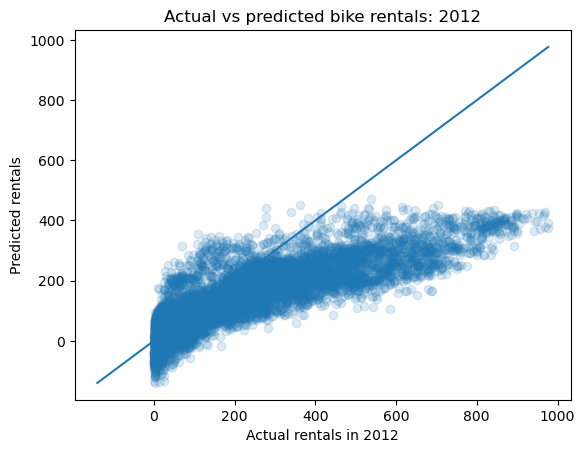

In [20]:
pred_2012 = final_model.predict(X_2012)

plt.scatter(y_2012, pred_2012, alpha=0.15)

low = min(y_2012.min(), pred_2012.min())
high = max(y_2012.max(), pred_2012.max())

plt.plot([low, high], [low, high])

plt.xlabel("Actual rentals in 2012")
plt.ylabel("Predicted rentals")
plt.title("Actual vs predicted bike rentals: 2012")
plt.show()

#### 시간대별 오류를 확인한다

운영자의 입장에서는 출퇴근 시간에 크게 틀리는 모델과  
새벽 시간에 크게 틀리는 모델의 의미가 다를 수 있다.

따라서 전체 평균 오차뿐 아니라 **시간대별 평균 절대오차**를 확인한다.

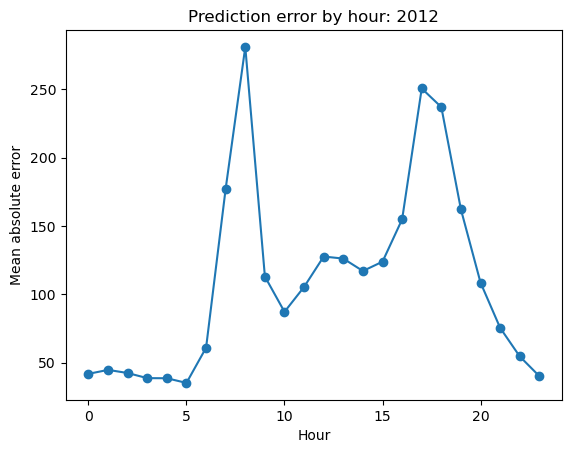

In [21]:
errors_2012 = pd.DataFrame({
    "hr": X_2012["hr"].to_numpy(),
    "workingday": X_2012["workingday"].to_numpy(),
    "weathersit": X_2012["weathersit"].to_numpy(),
    "actual": y_2012.to_numpy(),
    "predicted": pred_2012
})

errors_2012["error"] = (
    errors_2012["actual"]
    - errors_2012["predicted"]
)

errors_2012["abs_error"] = (
    errors_2012["error"].abs()
)

hour_error = (
    errors_2012
    .groupby("hr")["abs_error"]
    .mean()
)

hour_error.plot(marker="o")

plt.xlabel("Hour")
plt.ylabel("Mean absolute error")
plt.title("Prediction error by hour: 2012")
plt.show()

#### 조건을 하나 더 선택해 오류를 분석한다

이번에는 학생이 조건을 선택한다.

추천 후보:

- `workingday`
- `weathersit`

아래 코드의 `analysis_col`을 바꾸어 비교한다.

In [22]:
analysis_col = "workingday"  # TODO: 필요하면 "weathersit"으로 바꾼다.

condition_error = (
    errors_2012
    .groupby(analysis_col)["abs_error"]
    .agg(["mean", "median", "count"])
)

condition_error

,mean,median,count
workingday,,,
0,116.775068,75.816128,2780
1,107.317339,63.093520,5954


#### 프로젝트 기록 ⑥ — 오류 분석

**오차가 큰 시간대는 언제인가?**

> 작성:

**그 시간대에서 수요 자체가 높은가?**

> 작성:

**추가로 선택한 조건에서는 어느 집단의 오차가 큰가?**

> 작성:

**전체 RMSE만 보았다면 놓칠 수 있었던 사실은 무엇인가?**

> 작성:

**실제 운영에서 특히 주의해야 할 상황은 무엇인가?**

> 작성:

### 왜 2012년에서 성능이 달라졌는지 살펴본다

최종 평가가 끝났으므로 이제 2011년과 2012년 자체를 비교할 수 있다.

두 해의 수요 수준이 달라졌다면  
2011년에 학습한 관계가 2012년에서도 완전히 같다고 기대하기 어렵다.

In [23]:
df.groupby("yr")["cnt"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
yr,,,,,
0,143.794448,109.0,133.797854,1,651
1,234.666361,191.0,208.910941,1,977


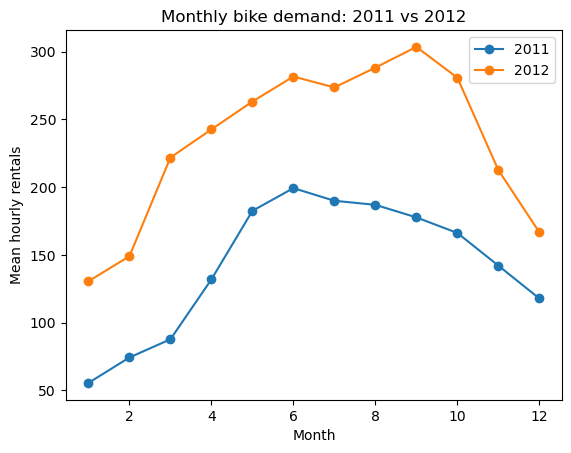

In [24]:
monthly = (
    df.groupby(["yr", "mnth"])["cnt"]
      .mean()
      .unstack(0)
)

monthly.columns = ["2011", "2012"]

monthly.plot(marker="o")

plt.xlabel("Month")
plt.ylabel("Mean hourly rentals")
plt.title("Monthly bike demand: 2011 vs 2012")
plt.show()

2011년과 2012년의 수요 수준이나 월별 모습이 다르다면 다음 가능성을 생각할 수 있다.

- 모델이 데이터의 관계를 충분히 표현하지 못했는가?
- 2011년 데이터에 지나치게 맞춰졌는가?
- 2012년의 수요 수준이나 변수 사이의 관계가 달라졌는가?
- 중요한 정보가 데이터에 빠져 있는가?

> **테스트 성능이 낮다는 사실과 그 이유에 대한 설명은 서로 다른 문제다.**  
> 데이터와 오류 분석 결과를 근거로 가능한 설명을 제시해야 한다.

### 예측 관계와 인과관계를 구분한다

모델이 `hr`, `temp`, `workingday` 같은 정보를 예측에 유용하게 사용했다고 해도 다음 두 문장은 다르다.

> “온도 정보는 자전거 대여량 **예측에 유용했다**.”

> “온도가 높아지면 자전거 대여가 **증가한다**.”

첫 번째는 예측에 관한 주장이다.  
두 번째는 인과관계로 해석될 수 있는 주장이다.

이번 프로젝트의 관찰 데이터와 예측 모델만으로는 인과관계를 쉽게 결론 내릴 수 없다.

### AI 체크포인트 ③ — 결과 해석 검토

최종 결과와 오류 분석을 AI에게 제공하고 다음처럼 요청할 수 있다.

> “다음 결과를 바탕으로 자전거 공유 서비스 운영자에게 전달할 결론 초안을 작성해줘.  
> 검증 결과와 2012년 최종 테스트 결과를 구분하고, 예측 관계를 인과관계로 표현하지 말아줘.  
> 모델의 한계도 함께 적어줘.”

AI가 작성한 문장에서 다음 문제가 있는지 직접 찾는다.

- 2013년 이후에도 같은 성능을 보장한다고 말하는가?
- 상관이나 예측 관계를 인과관계로 바꾸어 말하는가?
- 테스트 한 번으로 일반화가 완전히 증명됐다고 말하는가?
- 전체 성능만 보고 특정 시간대의 실패를 무시하는가?
- 데이터에서 확인할 수 없는 이유를 단정하는가?

**AI의 문장 중 수정하거나 받아들이지 않은 내용**

> 작성:

**그 이유**

> 작성:

### 최종 결론을 작성한다

좋은 결론은 성능 숫자를 나열하는 것으로 끝나지 않는다.

다음 순서로 작성한다.

#### 분석 질문에 대한 직접적인 답

> 2011년 데이터로 학습한 모델은 2012년의 시간당 자전거 수요를 ______ 정도로 예측했다.

#### 선택한 모델과 선택 근거

> 작성:

#### 핵심 성능과 의미

> 작성:

#### 모델이 특히 잘못되는 상황

> 작성:

#### 실제 운영에서의 활용 가능성

> 작성:

#### 분석의 한계 두 가지 이상

1. 작성:
2. 작성:

#### 다음 분석에서 추가하고 싶은 정보 또는 방법

> 작성:

### 프로젝트 최종 제출 전 확인

다음 항목을 모두 확인한다.

- [ ] 타깃과 문제 유형을 설명했다.
- [ ] 제외한 변수와 제외 이유를 설명했다.
- [ ] 2011년과 2012년의 역할을 구분했다.
- [ ] EDA 질문을 직접 만들고 결과를 해석했다.
- [ ] 전처리 방법과 그 이유를 설명했다.
- [ ] 기준선, 선형 회귀, Ridge를 같은 검증 데이터에서 비교했다.
- [ ] 검증 결과를 근거로 모델을 선택했다.
- [ ] 모델 선택이 끝난 뒤에만 2012년을 최종 평가했다.
- [ ] MAE, RMSE, R²를 현실의 언어로 해석했다.
- [ ] 전체 성능뿐 아니라 조건별 오류를 확인했다.
- [ ] 예측 관계와 인과관계를 구분했다.
- [ ] AI의 제안 중 하나 이상을 검토하고 수정 또는 수용한 근거를 남겼다.
- [ ] 분석의 한계를 최소 두 가지 적었다.

### 평가 기준

| 영역 | 배점 | 확인할 내용 |
|---|---:|---|
| 문제와 데이터 이해 | 4 | 타깃·특성·누수·시간적 분석 설계를 적절히 설명했는가? |
| 분석 방법 | 4 | EDA·전처리·모델 비교·검증 절차가 타당한가? |
| 결과 해석 | 5 | 지표와 그래프를 현실의 언어로 정확히 해석했는가? |
| 판단 | 4 | 모델 선택과 최종 결론에 자신의 근거가 있는가? |
| 검증과 한계 | 3 | AI 결과 검토, 오류 분석, 일반화와 한계를 적절히 다루었는가? |
| **합계** | **20** | |

코드의 길이나 화려함 자체는 평가의 중심이 아니다.

> **무엇을 했는지뿐 아니라 왜 그렇게 했는지를 설명할 수 있어야 한다.**